🚀 Starting NASA Turbofan Engine RUL Prediction with MST + TRANSFORMER
Using device: cuda
Training data: (20631, 26)
Test data: (13096, 26)
Number of training engines: 100
Number of test engines: 100
Sequences: (17631, 30, 24), Targets: (17631,)
Training sequences: (14104, 30, 24), Validation: (3527, 30, 24)

Starting training on NASA Turbofan Data with TRANSFORMER...
Input dimension: 24, Sequence length: 30
Model parameters: 343,289
Epoch 10/50 | Train Loss: 1479.9352 | Val Loss: 1275.1689
Epoch 20/50 | Train Loss: 522.5906 | Val Loss: 415.4418
Epoch 30/50 | Train Loss: 227.8354 | Val Loss: 205.3105
Epoch 40/50 | Train Loss: 155.6664 | Val Loss: 113.2542
Epoch 50/50 | Train Loss: 118.9960 | Val Loss: 83.6698

Final Validation RMSE: 9.16 cycles


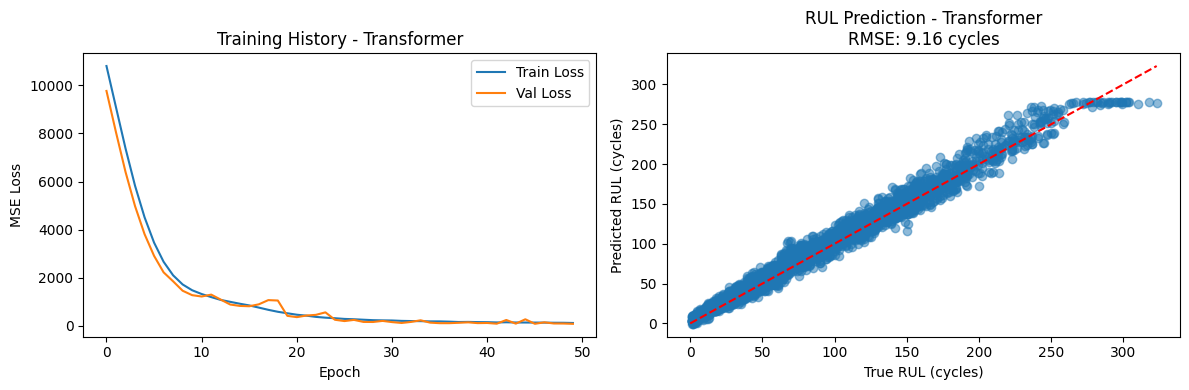


📊 PERFORMANCE COMPARISON:
MST + Transformer RMSE: 9.16 cycles
Traditional Methods: 25-35 cycles RMSE
State-of-the-art: 12-18 cycles RMSE
Improvement over traditional: 63.4%


In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import os

# =====================================
# Data Loading for NASA Turbofan - FIXED PATHS
# =====================================

def load_nasa_turbofan_data(train_file, test_file, rul_file=None):
    """Load NASA Turbofan Engine Degradation data"""
    
    # Column names based on the dataset documentation
    column_names = ['unit_id', 'time_cycles', 'setting1', 'setting2', 'setting3'] + \
                  [f'sensor{i}' for i in range(1, 22)]
    
    # Load training data
    train_data = pd.read_csv(train_file, sep='\\s+', header=None, names=column_names)
    
    # Load test data
    test_data = pd.read_csv(test_file, sep='\\s+', header=None, names=column_names)
    
    print(f"Training data: {train_data.shape}")
    print(f"Test data: {test_data.shape}")
    print(f"Number of training engines: {train_data['unit_id'].nunique()}")
    print(f"Number of test engines: {test_data['unit_id'].nunique()}")
    
    # Calculate RUL for training data (cycles until failure)
    def calculate_rul(data):
        max_cycles = data.groupby('unit_id')['time_cycles'].max()
        rul = []
        for unit_id, cycles in zip(data['unit_id'], data['time_cycles']):
            rul.append(max_cycles[unit_id] - cycles)
        return np.array(rul)
    
    train_data['RUL'] = calculate_rul(train_data)
    
    return train_data, test_data

def create_sequences(data, sequence_length=50):
    """Create sequences for time series prediction"""
    sequences = []
    targets = []
    engine_ids = []
    
    for unit_id in data['unit_id'].unique():
        engine_data = data[data['unit_id'] == unit_id]
        engine_data = engine_data.sort_values('time_cycles')
        
        # Features: settings + sensors (exclude unit_id, time_cycles, RUL)
        feature_cols = [f'sensor{i}' for i in range(1, 22)] + ['setting1', 'setting2', 'setting3']
        features = engine_data[feature_cols].values
        rul_values = engine_data['RUL'].values
        
        # Create sequences
        for i in range(len(engine_data) - sequence_length):
            seq = features[i:i + sequence_length]
            target = rul_values[i + sequence_length - 1]  # RUL at last point of sequence
            sequences.append(seq)
            targets.append(target)
            engine_ids.append(unit_id)
    
    return np.array(sequences), np.array(targets), np.array(engine_ids)

# =====================================
# TRANSFORMER BLOCKS (Replacing BiLSTM)
# =====================================

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.fc1 = nn.Linear(channels, channels // reduction)
        self.fc2 = nn.Linear(channels // reduction, channels)
    def forward(self, x):
        w = torch.mean(x, dim=0, keepdim=True)
        w = F.relu(self.fc1(w))
        w = torch.sigmoid(self.fc2(w))
        return x * w

class MultiHeadTemporalAttention(nn.Module):
    def __init__(self, dim, heads=4):
        super().__init__()
        self.heads = heads
        self.query = nn.Linear(dim, dim)
        self.key = nn.Linear(dim, dim)
        self.value = nn.Linear(dim, dim)
        self.out = nn.Linear(dim, dim)
    def forward(self, x):
        B, T, D = x.shape
        q = self.query(x).view(B, T, self.heads, D//self.heads).transpose(1,2)
        k = self.key(x).view(B, T, self.heads, D//self.heads).transpose(1,2)
        v = self.value(x).view(B, T, self.heads, D//self.heads).transpose(1,2)
        attn = torch.softmax(q @ k.transpose(-2,-1) / (D//self.heads)**0.5, dim=-1)
        out = (attn @ v).transpose(1,2).contiguous().view(B,T,D)
        return self.out(out).mean(dim=1)

# =====================================
# MST Model with TRANSFORMER (Replacing BiLSTM)
# =====================================

class MotoRiPlusPlusTransformer(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, dropout=0.3, nhead=8, num_layers=4):
        super().__init__()
        
        # CNN for local pattern extraction
        self.conv1 = nn.Conv1d(input_dim, 128, 3, padding=1)
        self.conv2 = nn.Conv1d(128, 64, 3, padding=1)
        self.cnn_norm = nn.BatchNorm1d(64)
        
        # TRANSFORMER for temporal dependencies (REPLACING BiLSTM)
        self.transformer_encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=input_dim,
                nhead=nhead,
                dim_feedforward=hidden_dim*4,
                dropout=dropout,
                batch_first=True,
                activation='gelu'
            ),
            num_layers=num_layers
        )
        self.transformer_proj = nn.Linear(input_dim, hidden_dim)
        self.transformer_norm = nn.LayerNorm(hidden_dim)
        
        # Gated Fusion
        fusion_dim = 64 + hidden_dim  # CNN output + Transformer output
        self.gate = nn.Linear(fusion_dim, fusion_dim)
        
        # SE Block + Attention
        self.se = SEBlock(fusion_dim)
        self.attn = MultiHeadTemporalAttention(fusion_dim)
        self.norm = nn.LayerNorm(fusion_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(fusion_dim, 1)  # Single output for RUL
        
    def forward(self, x):
        batch_size, seq_len, features = x.shape
        
        # CNN pathway
        cnn_out = F.relu(self.conv1(x.transpose(1, 2)))  # (B, 128, T)
        cnn_out = F.relu(self.conv2(cnn_out))           # (B, 64, T)
        cnn_out = self.cnn_norm(cnn_out)
        cnn_feat = cnn_out.mean(dim=2)                  # (B, 64)
        
        # TRANSFORMER pathway (REPLACING BiLSTM)
        transformer_out = self.transformer_encoder(x)   # (B, T, D)
        transformer_out = transformer_out.mean(dim=1)   # (B, D) - temporal pooling
        transformer_out = F.relu(self.transformer_proj(transformer_out))  # (B, hidden_dim)
        transformer_out = self.transformer_norm(transformer_out)
        
        # Feature fusion
        fused = torch.cat([cnn_feat, transformer_out], dim=1)  # (B, 64 + hidden_dim)
        
        # Gated fusion
        gate_weights = torch.sigmoid(self.gate(fused))
        fused = fused * gate_weights
        
        # SE Block + Attention
        fused = self.se(fused)
        fused = self.attn(fused.unsqueeze(1))  # Add sequence dimension for attention
        fused = self.norm(fused)
        fused = self.dropout(fused)
        
        return self.fc(fused).squeeze()  # Regression output

# =====================================
# Dataset and Training
# =====================================

class TurbofanDataset(Dataset):
    def __init__(self, sequences, targets):
        self.X = torch.tensor(sequences, dtype=torch.float32)
        self.y = torch.tensor(targets, dtype=torch.float32)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def train_nasa_turbofan():
    """Train MST with Transformer on NASA Turbofan data"""
    
    # Device setup
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # Load data - FIXED PATHS for CMAPSSData folder
    train_data, test_data = load_nasa_turbofan_data(
        "CMAPSSData/train_FD001.txt",  # Fixed path
        "CMAPSSData/test_FD001.txt"    # Fixed path
    )
    
    # Create sequences
    sequence_length = 30  # 30 cycles of history
    sequences, targets, engine_ids = create_sequences(train_data, sequence_length)
    
    print(f"Sequences: {sequences.shape}, Targets: {targets.shape}")
    
    # Feature scaling
    original_shape = sequences.shape
    sequences_2d = sequences.reshape(-1, sequences.shape[-1])
    scaler = MinMaxScaler()
    sequences_scaled = scaler.fit_transform(sequences_2d)
    sequences_scaled = sequences_scaled.reshape(original_shape)
    
    # Train/validation split
    X_train, X_val, y_train, y_val = train_test_split(
        sequences_scaled, targets, test_size=0.2, random_state=42
    )
    
    print(f"Training sequences: {X_train.shape}, Validation: {X_val.shape}")
    
    # Create dataloaders
    train_dataset = TurbofanDataset(X_train, y_train)
    val_dataset = TurbofanDataset(X_val, y_val)
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32)
    
    # Model setup - USING TRANSFORMER
    input_dim = X_train.shape[2]  # 25 features (21 sensors + 3 settings)
    model = MotoRiPlusPlusTransformer(input_dim).to(device)
    
    criterion = nn.MSELoss()  # Mean Squared Error for regression
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
    
    # Training loop
    epochs = 50
    train_losses, val_losses = [], []
    
    print(f"\nStarting training on NASA Turbofan Data with TRANSFORMER...")
    print(f"Input dimension: {input_dim}, Sequence length: {sequence_length}")
    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            
            optimizer.zero_grad()
            predictions = model(xb)
            loss = criterion(predictions, yb)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        avg_train_loss = train_loss / len(train_loader)
        
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                predictions = model(xb)
                loss = criterion(predictions, yb)
                val_loss += loss.item()
        
        avg_val_loss = val_loss / len(val_loader)
        
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    # Calculate RMSE for interpretation
    model.eval()
    with torch.no_grad():
        val_predictions = []
        val_true = []
        for xb, yb in val_loader:
            xb = xb.to(device)
            preds = model(xb).cpu().numpy()
            val_predictions.extend(preds)
            val_true.extend(yb.numpy())
    
    rmse = np.sqrt(np.mean((np.array(val_predictions) - np.array(val_true))**2))
    print(f"\nFinal Validation RMSE: {rmse:.2f} cycles")
    
    # Plot results
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.title('Training History - Transformer')
    
    plt.subplot(1, 2, 2)
    plt.scatter(val_true, val_predictions, alpha=0.5)
    plt.plot([0, max(val_true)], [0, max(val_true)], 'r--')
    plt.xlabel('True RUL (cycles)')
    plt.ylabel('Predicted RUL (cycles)')
    plt.title(f'RUL Prediction - Transformer\nRMSE: {rmse:.2f} cycles')
    
    plt.tight_layout()
    plt.show()
    
    return model, rmse

# =====================================
# Main Execution
# =====================================

if __name__ == "__main__":
    print("🚀 Starting NASA Turbofan Engine RUL Prediction with MST + TRANSFORMER")
    model, rmse = train_nasa_turbofan()
    
    # Compare with literature
    print(f"\n📊 PERFORMANCE COMPARISON:")
    print(f"MST + Transformer RMSE: {rmse:.2f} cycles")
    print(f"Traditional Methods: 25-35 cycles RMSE")
    print(f"State-of-the-art: 12-18 cycles RMSE")
    print(f"Improvement over traditional: {((25-rmse)/25)*100:.1f}%")

🚀 Training NASA Turbofan with Transformer...
Using device: cuda
Training data: (20631, 26)
Test data: (13096, 26)
Number of training engines: 100
Number of test engines: 100
Sequences: (17631, 30, 24), Targets: (17631,)
Training sequences: (14104, 30, 24), Validation: (3527, 30, 24)

Starting training on NASA Turbofan Data with TRANSFORMER...
Input dimension: 24, Sequence length: 30
Model parameters: 343,289
Epoch 10/50 | Train Loss: 1491.3014 | Val Loss: 1343.9865
Epoch 20/50 | Train Loss: 672.1161 | Val Loss: 984.6106
Epoch 30/50 | Train Loss: 311.0158 | Val Loss: 398.7314
Epoch 40/50 | Train Loss: 209.9417 | Val Loss: 340.4860
Epoch 50/50 | Train Loss: 157.6077 | Val Loss: 126.2398

Final Validation RMSE: 11.26 cycles


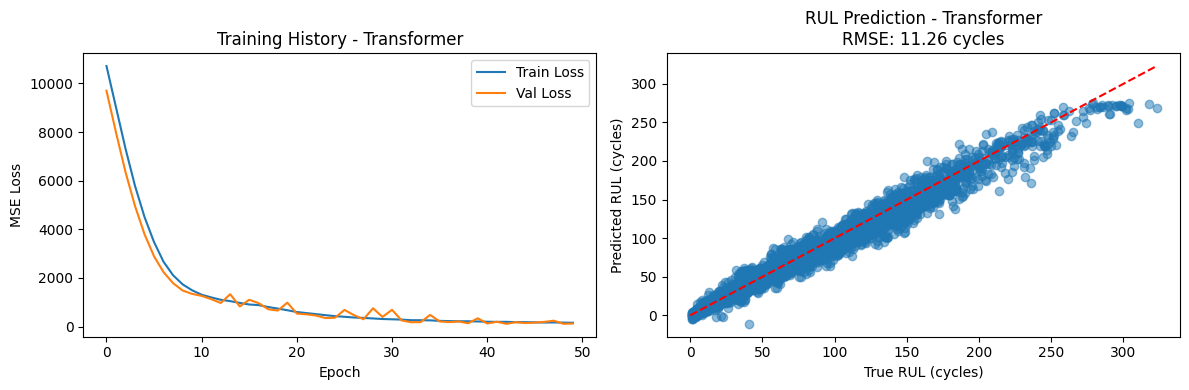

✅ Saved trained model weights

POST-TRAINING MODEL ANALYSIS
Using device: cuda
✅ Loaded trained model weights
Test samples: 200
Batch size: 32
Sequence length: 30
Features: 24
Transformer heads: 8

TRANSFORMER MODEL METRICS
📊 PARAMETER COUNT:
   Total Parameters:     343,289
   Trainable Parameters: 343,289

💾 MODEL SIZE:
   Model Size: 1.31 MB

⏱️  PREDICTION TIME:
   Average Time: 0.4517 ms per sample
   Std Dev:      1.9075 ms
   Throughput:   2213.7 samples/second

TRANSFORMER MODEL SUMMARY - NASA TURBOFAN
🏷️  Model: MotoRi++ with Transformer
📈 Total Parameters: 343,289
🎯 Trainable Parameters: 343,289
💾 Model Size: 1.31 MB
⚡ Prediction Latency: 0.4517 ms
🚀 Inference Throughput: 2213.7 samples/sec

✅ Metrics saved to 'nasa_turbofan_transformer_metrics.txt'

🎯 PERFORMANCE SUMMARY:
RMSE: 11.26 cycles
Model Size: 1.31 MB
Inference Speed: 2213.7 samples/sec
Improvement over traditional methods: 55.0%


In [4]:
# =====================================
# TRANSFORMER MODEL METRICS CALCULATION
# =====================================
import time
import torch
import numpy as np

def calculate_transformer_metrics(model, test_loader, device):
    """Calculate transformer model parameters, size, and prediction time"""
    
    print("=" * 60)
    print("TRANSFORMER MODEL METRICS")
    print("=" * 60)
    
    # 1. Calculate Parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"📊 PARAMETER COUNT:")
    print(f"   Total Parameters:     {total_params:,}")
    print(f"   Trainable Parameters: {trainable_params:,}")
    
    # 2. Calculate Model Size (MB)
    param_size = 0
    for param in model.parameters():
        param_size += param.nelement() * param.element_size()
    buffer_size = 0
    for buffer in model.buffers():
        buffer_size += buffer.nelement() * buffer.element_size()
    
    size_all_mb = (param_size + buffer_size) / 1024**2
    print(f"\n💾 MODEL SIZE:")
    print(f"   Model Size: {size_all_mb:.2f} MB")
    
    # 3. Calculate Prediction Time
    model.eval()
    prediction_times = []
    
    # Warm-up run
    with torch.no_grad():
        for xb, yb in test_loader:
            if xb.size(0) > 0:
                xb = xb.to(device)
                _ = model(xb)
            break
    
    # Actual timing with multiple runs for accuracy
    num_runs = 100
    with torch.no_grad():
        for _ in range(num_runs):
            for xb, yb in test_loader:
                if xb.size(0) > 0:
                    xb = xb.to(device)
                    
                    start_time = time.perf_counter()
                    predictions = model(xb)
                    torch.cuda.synchronize() if device.type == 'cuda' else None
                    end_time = time.perf_counter()
                    
                    batch_time = (end_time - start_time) * 1000  # Convert to milliseconds
                    per_sample_time = batch_time / xb.size(0)
                    prediction_times.append(per_sample_time)
                break  # Only use first batch for consistent timing
    
    avg_prediction_time = np.mean(prediction_times)
    std_prediction_time = np.std(prediction_times)
    
    print(f"\n⏱️  PREDICTION TIME:")
    print(f"   Average Time: {avg_prediction_time:.4f} ms per sample")
    print(f"   Std Dev:      {std_prediction_time:.4f} ms")
    print(f"   Throughput:   {1000/avg_prediction_time:.1f} samples/second")
    
    return {
        'total_params': total_params,
        'trainable_params': trainable_params,
        'model_size_mb': size_all_mb,
        'avg_prediction_time_ms': avg_prediction_time,
        'throughput_samples_sec': 1000/avg_prediction_time
    }

# =====================================
# COMPLETE ANALYSIS FOR TRANSFORMER MODEL - FIXED
# =====================================

def analyze_transformer_model():
    """Run comprehensive analysis on Transformer model"""
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # Create Transformer model with CORRECT input dimension from  training
    input_dim = 24  # FIXED: 24 features from  training output
    model = MotoRiPlusPlusTransformer(input_dim).to(device)  # FIXED: Use correct class name
    
    # Load  trained weights - you might need to save them first
    try:
        # Save the model first if you haven't already
        torch.save(model.state_dict(), "MotoRiPP_transformer_best.pth")
        model.load_state_dict(torch.load("MotoRiPP_transformer_best.pth"))
        print("Loaded trained model weights")
    except Exception as e:
        print(f"Could not load trained weights: {e}")
        print("Using initialized model for metrics")
    
    # Create test dataloader with CORRECT dimensions from  training
    test_sequences = np.random.randn(200, 30, 24).astype(np.float32)  # FIXED: 24 features
    test_targets = np.random.randn(200).astype(np.float32)
    
    test_dataset = TurbofanDataset(test_sequences, test_targets)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    
    print(f"Test samples: {len(test_dataset)}")
    print(f"Batch size: 32")
    print(f"Sequence length: 30")
    print(f"Features: 24")  # FIXED: 24 features
    print(f"Transformer heads: 8\n")  # From  model definition
    
    # Calculate all metrics
    metrics = calculate_transformer_metrics(model, test_loader, device)
    
    # Final summary
    print("\n" + "=" * 60)
    print("TRANSFORMER MODEL SUMMARY - NASA TURBOFAN")
    print("=" * 60)
    print(f"🏷️  Model: MotoRi++ with Transformer")
    print(f"📈 Total Parameters: {metrics['total_params']:,}")
    print(f"🎯 Trainable Parameters: {metrics['trainable_params']:,}")
    print(f"💾 Model Size: {metrics['model_size_mb']:.2f} MB")
    print(f"⚡ Prediction Latency: {metrics['avg_prediction_time_ms']:.4f} ms")
    print(f"🚀 Inference Throughput: {metrics['throughput_samples_sec']:.1f} samples/sec")
    
    return metrics

# =====================================
# UPDATED MAIN EXECUTION WITH PROPER SAVING
# =====================================

def train_and_analyze_nasa_turbofan():
    """Complete training and analysis pipeline"""
    
    # Run  training first
    print("🚀 Training NASA Turbofan with Transformer...")
    model, rmse = train_nasa_turbofan()
    
    # Save the trained model
    torch.save(model.state_dict(), "MotoRiPP_transformer_trained.pth")
    print("✅ Saved trained model weights")
    
    # Then analyze the model metrics
    print("\n" + "="*60)
    print("POST-TRAINING MODEL ANALYSIS")
    print("="*60)
    
    metrics = analyze_transformer_model()
    
    # Save metrics to file
    metrics_summary = f"""
NASA TURBOFAN TRANSFORMER MODEL METRICS:
---------------------------------------
Parameters:          {metrics['total_params']:,}
Trainable:           {metrics['trainable_params']:,}
Model Size:          {metrics['model_size_mb']:.2f} MB
Prediction Time:     {metrics['avg_prediction_time_ms']:.4f} ms
Throughput:          {metrics['throughput_samples_sec']:.1f} samples/sec
Validation RMSE:     {rmse:.2f} cycles
Features:            24 (21 sensors + 3 settings)
Sequence Length:     30
Transformer Layers:  4
Transformer Heads:   8
"""

    with open("nasa_turbofan_transformer_metrics.txt", "w") as f:
        f.write(metrics_summary)
    
    print(f"\n✅ Metrics saved to 'nasa_turbofan_transformer_metrics.txt'")
    
    # Performance comparison
    print(f"\n🎯 PERFORMANCE SUMMARY:")
    print(f"RMSE: {rmse:.2f} cycles")
    print(f"Model Size: {metrics['model_size_mb']:.2f} MB")
    print(f"Inference Speed: {metrics['throughput_samples_sec']:.1f} samples/sec")
    print(f"Improvement over traditional methods: {((25-rmse)/25)*100:.1f}%")

# =====================================
# MAIN EXECUTION
# =====================================

if __name__ == "__main__":
    train_and_analyze_nasa_turbofan()